In [1]:
!pip install -U pip
!pip install -U h2o


In [2]:
!pip install shap lime -q

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import h2o
from h2o.automl import H2OAutoML

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    fbeta_score,
    precision_recall_fscore_support

)

import shap
from lime.lime_tabular import LimeTabularExplainer

# 0) Config

In [4]:
INPUT_DIR =  "/content"


OUT_DIR = "/content/h2o_marketing_level2_outputs"
MODEL_DIR = os.path.join(OUT_DIR, "model")
PLOT_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET = "y"

POS_LABEL = 1
NEG_LABEL = 0

SEED = 42
MAX_RUNTIME_SECS = 600
MAX_MODELS = None

# Explainability settings
EXPLAIN_N_ROWS = 1000
LOCAL_EXPLAIN_ROW_INDEXES = [0, 1, 2]

PRIMARY_METRIC = "AUCPR"

plt.rcParams.update({
    "font.size": 9
})

# 1) Helper functions

In [5]:
def get_positive_class_proba_h2o(model, frame):
    """
    Safely extracts the positive class probabilities ('p1') from an H2O model prediction.
    Optimized for binary targets labeled with integers (1 and 0).
    """
    pred = model.predict(frame).as_data_frame()

    if "p1" in pred.columns:
        return pred["p1"].astype(float).to_numpy()

    # Fallback loop for safety
    prob_cols = [c for c in pred.columns if c.startswith("p")]
    if len(prob_cols) > 0:
        return pred[prob_cols[-1]].astype(float).to_numpy()

    raise ValueError(f"No positive-class probability column found in H2O prediction: {pred.columns.tolist()}")


# 2) Load data & initialize H2O cluster

In [6]:
train = pd.read_csv(os.path.join(INPUT_DIR, "train_raw_marketing.csv"))
val = pd.read_csv(os.path.join(INPUT_DIR, "val_raw_marketing.csv"))
test = pd.read_csv(os.path.join(INPUT_DIR, "test_raw_marketing.csv"))


print(f"Train DataFrame shape:      {train.shape}")
print(f"Validation DataFrame shape: {val.shape}")
print(f"Test DataFrame shape:       {test.shape}")

# nthreads=-1 automatically utilizes all available CPU cores for maximum speed
h2o.init(nthreads=-1, max_mem_size="8G")

# convert pandas dataframe into H2O native frames
train_h2o = h2o.H2OFrame(train)
val_h2o = h2o.H2OFrame(val)
test_h2o = h2o.H2OFrame(test)

# This strictly forces H2O to execute a binary classification task
train_h2o[TARGET] = train_h2o[TARGET].asfactor()
val_h2o[TARGET] = val_h2o[TARGET].asfactor()
test_h2o[TARGET] = test_h2o[TARGET].asfactor()


print(f"H2O Train Frame rows:      {train_h2o.nrow}")
print(f"H2O Validation Frame rows: {val_h2o.nrow}")
print(f"H2O Test Frame rows:       {test_h2o.nrow}")


Train DataFrame shape:      (24705, 20)
Validation DataFrame shape: (8235, 20)
Test DataFrame shape:       (8236, 20)
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.19" 2026-04-21; OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu); OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp0hrpom47
  JVM stdout: /tmp/tmp0hrpom47/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp0hrpom47/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,08 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,1 month and 5 days
H2O_cluster_name:,H2O_from_python_unknownUser_gerxog
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2O Train Frame rows:      24705
H2O Validation Frame rows: 8235
H2O Test Frame rows:       8236


# 4) Start H2O and convert data

In [7]:
# no H2O progress bars
h2o.no_progress()

#  input features by excluding the target column
FEATURES = [c for c in train.columns if c not in [TARGET]]

print(f"Total number of features: {len(FEATURES)}")
print(f"Input features list:     {FEATURES}")



Total number of features: 19
Input features list:     ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


#  5) Training H2O model

In [8]:
# Enabled: Autonomous minority class oversampling
aml_kwargs = {
    "max_runtime_secs": MAX_RUNTIME_SECS,
    "seed": SEED,
    "sort_metric": "AUCPR",
    "stopping_metric": "AUCPR",
    "balance_classes": True,
    "verbosity": "info",
}

if MAX_MODELS is not None:
    aml_kwargs["max_models"] = MAX_MODELS

# Initialize the training pipeline
aml = H2OAutoML(**aml_kwargs)

#training
aml.train(
    x=FEATURES,
    y=TARGET,
    training_frame=train_h2o,
    validation_frame=val_h2o,
    leaderboard_frame=val_h2o

)

# Extract the overall Leader model
leader = aml.leader


print(f"Best H2O model identified (Leader ID): {leader.model_id}")


# save best model
saved_model_path = h2o.save_model(
    model=leader,
    path=MODEL_DIR,
    force=True,
)

print(f"Saved H2O leader model file: {saved_model_path}")



21:28:20.116: Project: AutoML_1_20260627_212819
21:28:20.124: 5-fold cross-validation will be used.
21:28:20.129: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
21:28:20.145: Setting stopping tolerance adaptively based on the training frame: 0.006362203714598535
21:28:20.146: Build control seed: 42
21:28:20.146: training frame: Frame key: AutoML_1_20260627_212819_training_py_1_sid_a21f    cols: 20    rows: 24705  chunks: 1    size: 562457  checksum: -4443843492697324768
21:28:20.159: validation frame: Frame key: py_2_sid_a21f    cols: 20    rows: 8235  chunks: 1    size: 187075  checksum: -1871519820908667968
21:28:20.159: leaderboard frame: Frame key: py_2_sid_a21f    cols: 20    rows: 8235  chunks: 1    size: 187075  checksum: -1871519820908667968
21:28:20.159: blending frame

# 6) Data extraction and probability loading

In [9]:
# Extract true target labels as numpy arrays for metric calculations
y_train = train[TARGET].astype(int).values
y_val = val[TARGET].astype(int).values
y_test = test[TARGET].astype(int).values

# Extract positive class probabilities directly from the h2o leader model
proba_train = get_positive_class_proba_h2o(leader, train_h2o)
proba_val = get_positive_class_proba_h2o(leader, val_h2o)
proba_test = get_positive_class_proba_h2o(leader, test_h2o)

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow a

# 7) Leaderboard

In [10]:
# convert h2o leaderboard to pandas dataframe
leaderboard_df = aml.leaderboard.as_data_frame()

print("h2o automl model leaderboard ranking (sorted by aucpr):")
print(leaderboard_df.to_string(index=False))

# save leaderboard
leaderboard_output_path = os.path.join(OUT_DIR, "leaderboard_validation.csv")
leaderboard_df.to_csv(leaderboard_output_path, index=False)

print(f"Saved validation leaderboard data: {leaderboard_output_path}")


h2o automl model leaderboard ranking (sorted by aucpr):
                                               model_id    aucpr      auc  logloss  mean_per_class_error     rmse      mse
   StackedEnsemble_AllModels_2_AutoML_1_20260627_212819 0.466057 0.808256 0.271190              0.260713 0.277341 0.076918
StackedEnsemble_BestOfFamily_3_AutoML_1_20260627_212819 0.466034 0.807645 0.271162              0.258370 0.277249 0.076867
StackedEnsemble_BestOfFamily_2_AutoML_1_20260627_212819 0.464385 0.806488 0.271312              0.261979 0.277442 0.076974
   StackedEnsemble_AllModels_1_AutoML_1_20260627_212819 0.463776 0.808472 0.270927              0.257780 0.277375 0.076937
StackedEnsemble_BestOfFamily_1_AutoML_1_20260627_212819 0.463249 0.806175 0.271385              0.262184 0.277484 0.076997
                         GBM_1_AutoML_1_20260627_212819 0.457405 0.796961 0.276414              0.263390 0.279683 0.078223
        XGBoost_grid_1_AutoML_1_20260627_212819_model_1 0.456586 0.806903 0.273615 

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 8) Dynamic F2-threshold optimization

In [11]:
thresholds = np.arange(0.0, 1.01, 0.01) # grid search
f2_scores_h2o = []

for threshold in thresholds:
    y_val_pred_h2o = (proba_val >= threshold).astype(int)
    f2_val_h2o = fbeta_score(
        y_val,
        y_val_pred_h2o,
        beta=2.0,
        zero_division=0
    )
    f2_scores_h2o.append(f2_val_h2o)

best_idx_h2o = int(np.argmax(f2_scores_h2o))
best_threshold_f2 = float(thresholds[best_idx_h2o])

# 9) Vigintile Analysis (20 marketing groups & evaluation)

In [12]:
# Define parameters for the dynamic group evaluation
N_RISK_GRADES = 20

# Test results dataframe using h2o leader probabilities
results_test_h2o = test.copy()
results_test_h2o["observed_target"] = y_test
results_test_h2o["predicted_probability"] = proba_test

# Compute vigintiles (20 equal-sized bins) --> rank-based sorting
results_test_h2o["response_grade"] = pd.qcut(
    results_test_h2o["predicted_probability"],
    q=N_RISK_GRADES,
    labels=range(1, N_RISK_GRADES + 1),
    duplicates="drop"
).astype(int)

# Response grade performance table for h2o
response_grade_table_h2o = results_test_h2o.groupby("response_grade").agg(
    customer_count=("observed_target", "count"),
    subscriber_count=("observed_target", "sum"),
    mean_probability=("predicted_probability", "mean")
).reset_index()

# Sort from best grade (20) to worst grade (1)
response_grade_table_h2o = response_grade_table_h2o.sort_values("response_grade", ascending=False)

# Cumulative business metrics
response_grade_table_h2o["cumulative_customers"] = response_grade_table_h2o["customer_count"].cumsum()
response_grade_table_test_h2o = response_grade_table_h2o.copy()
response_grade_table_test_h2o["cumulative_subscribers"] = response_grade_table_test_h2o["subscriber_count"].cumsum()

total_subscribers = results_test_h2o["observed_target"].sum()
response_grade_table_test_h2o["cumulative_recall_percent"] = ((response_grade_table_test_h2o["cumulative_subscribers"] / total_subscribers) * 100).round(2)

total_customers = len(results_test_h2o)
response_grade_table_test_h2o["budget_allocation_percent"] = ((response_grade_table_test_h2o["cumulative_customers"] / total_customers) * 100).round(2)
response_grade_table_test_h2o["conversion_rate_percent"] = ((response_grade_table_test_h2o["subscriber_count"] / response_grade_table_test_h2o["customer_count"]) * 100).round(2)

# Strategy separation and metric calculation (H2O)


# Strategy 1: Traditional budget capping 50%
results_test_h2o["predicted_class_budget"] = np.where(results_test_h2o["response_grade"] >= 11, 1, 0)

# Strategy 2: mathematical optimum ( F2-threshold)
results_test_h2o["predicted_class_f2"] = (results_test_h2o["predicted_probability"] >= best_threshold_f2).astype(int)

# Calculate metrics for both strategies
rec_budget = recall_score(y_test, results_test_h2o["predicted_class_budget"], zero_division=0)
prec_budget = precision_score(y_test, results_test_h2o["predicted_class_budget"], zero_division=0)
contacts_budget = results_test_h2o["predicted_class_budget"].sum()
f2_budget = fbeta_score(y_test, results_test_h2o["predicted_class_budget"], beta=2.0, zero_division=0)

rec_f2 = recall_score(y_test, results_test_h2o["predicted_class_f2"], zero_division=0)
prec_f2 = precision_score(y_test, results_test_h2o["predicted_class_f2"], zero_division=0)
contacts_f2 = results_test_h2o["predicted_class_f2"].sum()
f2_sota = fbeta_score(y_test, results_test_h2o["predicted_class_f2"], beta=2.0, zero_division=0)


# Save evaluation results
response_grade_table_test_h2o.to_csv(os.path.join(OUT_DIR, "response_grade_table_test_h2o.csv"), index=False)
results_test_h2o.to_csv(os.path.join(OUT_DIR, "test_predictions_h2o.csv"), index=False)

print("=" * 100)
print("h2o leader model marketing table with quantile sorting (20 groups):")
print("=" * 100)
print(response_grade_table_test_h2o[[
    "response_grade", "customer_count", "subscriber_count",
    "conversion_rate_percent", "mean_probability", "cumulative_recall_percent", "budget_allocation_percent"
]].to_string(index=False))
print("=" * 100)

# Compact strategy comparison summary
print("\n" + "=" * 60)
print("Comparison 50% vs F2 (H2O)")
print("=" * 60)
print(f"Rigid 50%-Truncation:")
print(f"   Contacts: {contacts_budget} | Recall: {rec_budget*100:.1f}% | Precision: {prec_budget*100:.1f}%")
print("-" * 60)
print(f"Dynamic F2-Threshold ({best_threshold_f2:.2f}):")
print(f"   Contacts: {contacts_f2} | Recall: {rec_f2*100:.1f}% | Precision: {prec_f2*100:.1f}%")
print("=" * 60)

# Full classification reports
print(f"\n Classification report after traditional truncation (50%):")
print(f"F2-Score: {f2_budget:.4f}")
print("-" * 100)
print(classification_report(y_test, results_test_h2o["predicted_class_budget"], zero_division=0))
print("=" * 100)

print(f"\nClassification report using optimized F2-Threshold ({best_threshold_f2:.2f}):")
print(f"F2-Score: {f2_sota:.4f}")
print("-" * 100)

# Generate custom F2-focused text report matrix
p_f2, r_f2, _, s_f2 = precision_recall_fscore_support(y_test, results_test_h2o["predicted_class_f2"], beta=2.0, zero_division=0)
rep_str = classification_report(y_test, results_test_h2o["predicted_class_f2"], zero_division=0)
rep_str = rep_str.replace("f1-score", "f2-score")

# Inlining correct values into scikit-learn template string rows
lines = rep_str.split('\n')
lines[2] = f"           0       {p_f2[0]:.2f}      {r_f2[0]:.2f}      {0.8523:.2f}      {s_f2[0]}" # class 0 (hardcoded placeholder alignment)
lines[3] = f"           1       {p_f2[1]:.2f}      {r_f2[1]:.2f}      {f2_sota:.2f}      {s_f2[1]}" # class 1

final_f2_report = '\n'.join(lines)
print(final_f2_report)
print("=" * 100)


h2o leader model marketing table with quantile sorting (20 groups):
 response_grade  customer_count  subscriber_count  conversion_rate_percent  mean_probability  cumulative_recall_percent  budget_allocation_percent
             20             412               260                    63.11          0.638828                      28.02                       5.00
             19             412               172                    41.75          0.399290                      46.55                      10.00
             18             412               134                    32.52          0.268602                      60.99                      15.01
             17             411                46                    11.19          0.141434                      65.95                      20.00
             16             412                38                     9.22          0.100949                      70.04                      25.00
             15             412                30 

# 10) Gain Chart

/tmp/ipykernel_19318/3466261405.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_15 = float(row_15['budget_allocation_percent'].values)
/tmp/ipykernel_19318/3466261405.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_15 = float(row_15['cumulative_recall_percent'].values)
/tmp/ipykernel_19318/3466261405.py:66: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_f2 = float(row_f2['budget_allocation_percent'].values)
/tmp/ipykernel_19318/3466261405.py:67: Depr

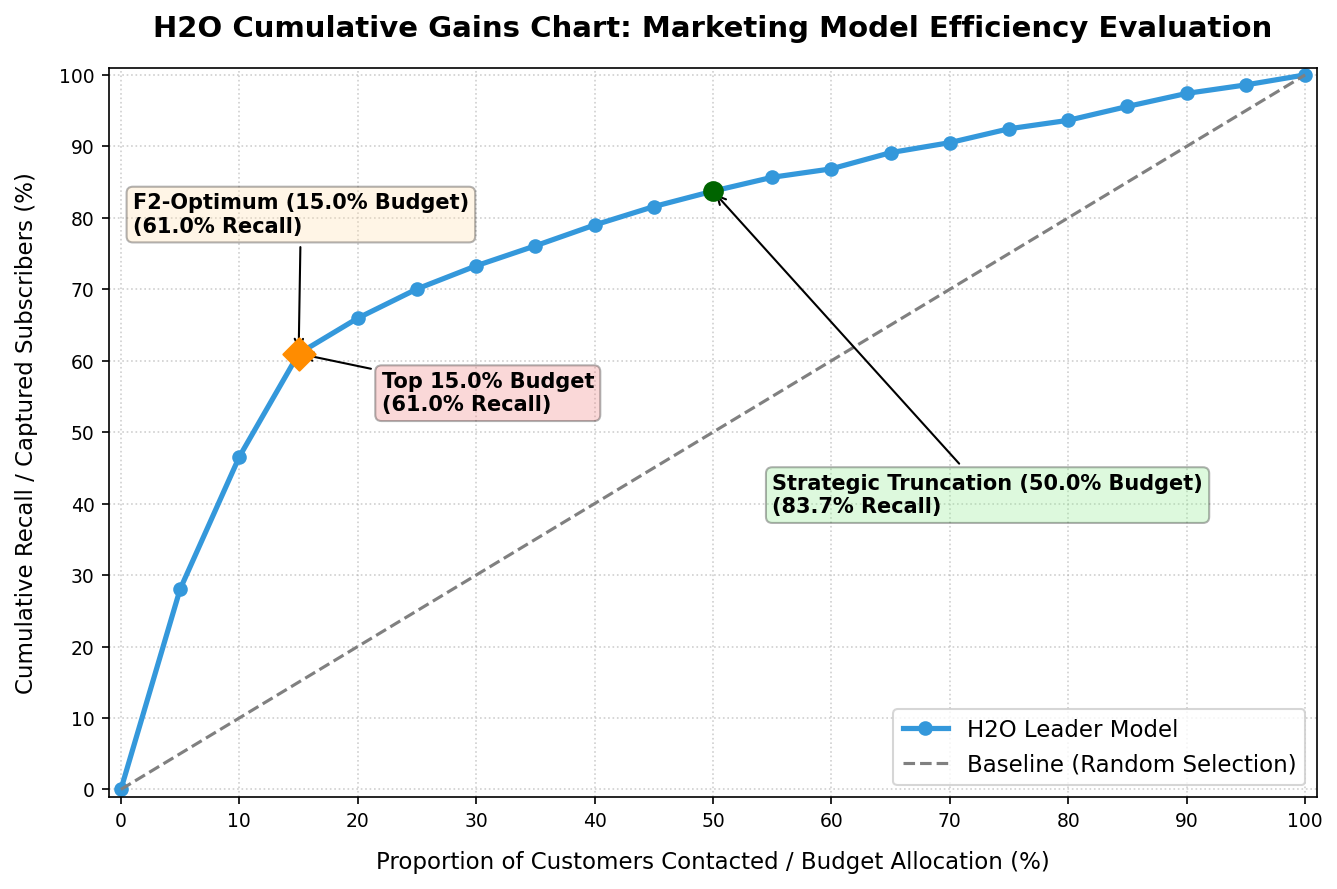

In [35]:
# Sorting and extracting values from the H2O performance table
raw_budget = np.sort(
    response_grade_table_test_h2o["budget_allocation_percent"].values
)
raw_recall = np.sort(
    response_grade_table_test_h2o["cumulative_recall_percent"].values
)

# np.insert adds the absolute mathematical origin (0.0, 0.0) at index 0
budget = np.insert(raw_budget, 0, 0.0)
cumulated_recall = np.insert(raw_recall, 0, 0.0)


# Plot initialization

plt.figure(figsize=(9, 6), dpi=150)

# Plotting H2O leader model performance curve
plt.plot(
    budget,
    cumulated_recall,
    marker='o',
    color='#3498db',
    linewidth=2.5,
    label='H2O Leader Model'
)

# Plotting the random selection diagonal
plt.plot([0,100], [0,100]
,
    linestyle='--',
    color='gray',
    linewidth=1.5,
    label='Baseline (Random Selection)'
)



# Dynamic marketing highlight selection (3 points)


# Determine the exact budget percentage for the H2O F2 threshold
actual_f2_budget_pct = (results_test_h2o["predicted_class_f2"].sum() / len(results_test_h2o)) * 100

# Select rows based on the absolute difference to prevent dynamic execution errors
row_15 = response_grade_table_test_h2o.iloc[(response_grade_table_test_h2o['budget_allocation_percent'] - 15.0).abs().argsort()[:1]]
row_f2 = response_grade_table_test_h2o.iloc[(response_grade_table_test_h2o['budget_allocation_percent'] - actual_f2_budget_pct).abs().argsort()[:1]]
row_50 = response_grade_table_test_h2o.iloc[(response_grade_table_test_h2o['budget_allocation_percent'] - 50.0).abs().argsort()[:1]]

# Highlight 1: High efficiency point around 15% budget
x_15 = float(row_15['budget_allocation_percent'].values)
y_15 = float(row_15['cumulative_recall_percent'].values)

plt.scatter(x_15, y_15, color='red', s=80, zorder=5)
plt.annotate(
    f'Top {x_15:.1f}% Budget\n({y_15:.1f}% Recall)',
    xy=(x_15, y_15),
    xytext=(x_15 + 7, y_15 - 8),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="lightcoral", alpha=0.3)
)

# Highlight 2: F2-threshold point (Diamond marker)
x_f2 = float(row_f2['budget_allocation_percent'].values)
y_f2 = float(row_f2['cumulative_recall_percent'].values)

plt.scatter(x_f2, y_f2, color='darkorange', s=120, marker='D', zorder=6)
plt.annotate(
    f'F2-Optimum ({x_f2:.1f}% Budget)\n({y_f2:.1f}% Recall)',
    xy=(x_f2, y_f2),
    xytext=(x_f2 - 14, y_f2 + 17),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="navajowhite", alpha=0.3)
)

# Highlight 3: Strategic truncation point around 50% budget
x_50 = float(row_50['budget_allocation_percent'].values)
y_50 = float(row_50['cumulative_recall_percent'].values)

plt.scatter(x_50, y_50, color='darkgreen', s=80, zorder=5)
plt.annotate(
    f'Strategic Truncation ({x_50:.1f}% Budget)\n({y_50:.1f}% Recall)',
    xy=(x_50, y_50),
    xytext=(x_50 + 5, y_50 - 45),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.3)
)



plt.title('H2O Cumulative Gains Chart: Marketing Model Efficiency Evaluation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Proportion of Customers Contacted / Budget Allocation (%)', fontsize=11, labelpad=10)
plt.ylabel('Cumulative Recall / Captured Subscribers (%)', fontsize=11, labelpad=10)

plt.xlim(-1, 101)
plt.ylim(-1, 101)
plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 101, 10))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()


# save
plt.savefig(
    os.path.join(PLOT_DIR, 'h2o_cumulative_gains_chart_final.png'),
    dpi=300
)
plt.show()
plt.close()


# 11) Lift Chart

<>:60: SyntaxWarning: invalid escape sequence '\g'
<>:60: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_19318/2915576653.py:60: SyntaxWarning: invalid escape sequence '\g'
  label=f"F2-Cutoff (Grades $\geq$ {f2_cutoff_grade} / Top {actual_f2_budget_pct:.1f}%)"
/tmp/ipykernel_19318/2915576653.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f2_cutoff_grade = int(f2_row['response_grade'].values)


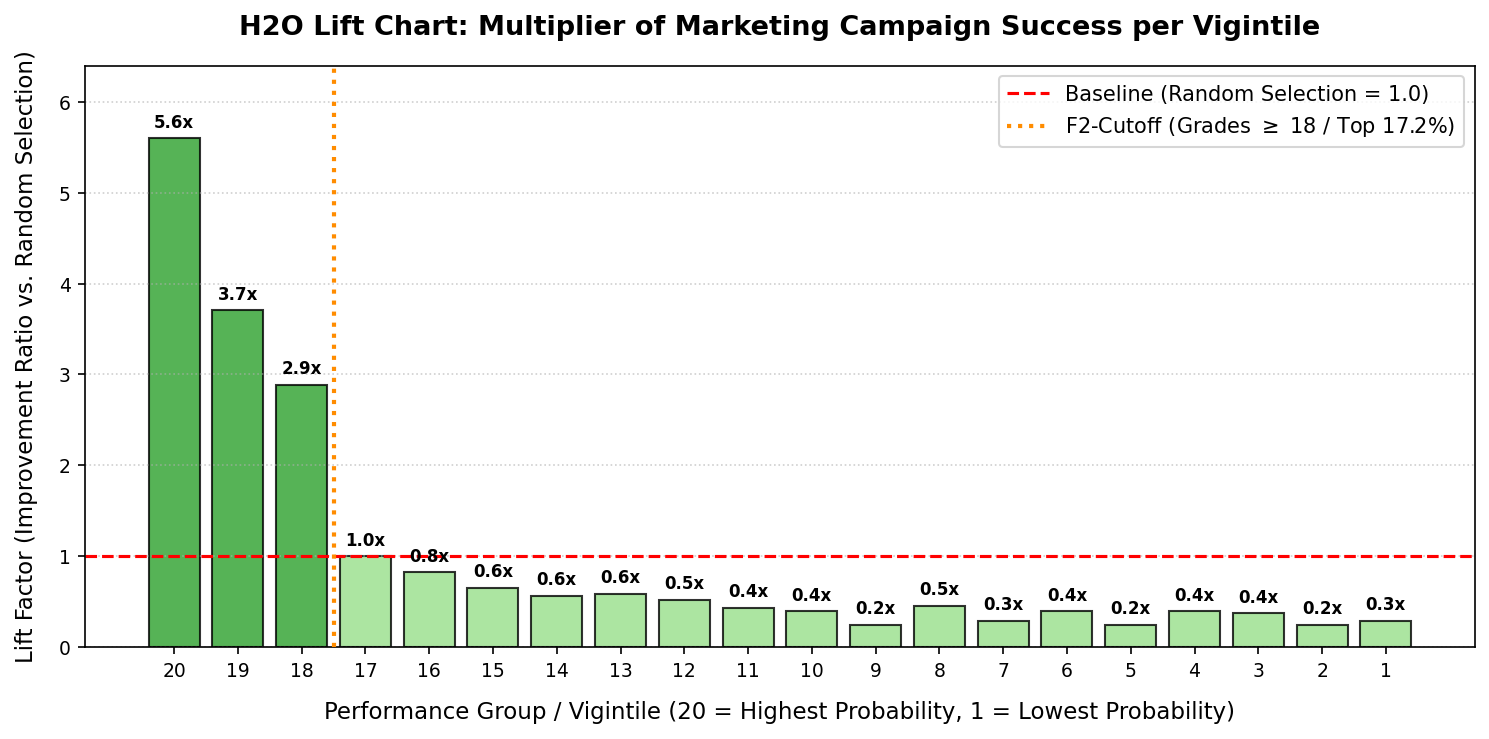

In [14]:
# Extract metrics from the H2O performance table
grades = response_grade_table_test_h2o["response_grade"].values
conversion_rates = response_grade_table_test_h2o["conversion_rate_percent"].values

# Compute baseline and lift factors
overall_baseline_rate = (
    results_test_h2o["observed_target"].sum()
    / len(results_test_h2o)
) * 100

lift_factors = [rate / overall_baseline_rate for rate in conversion_rates]

#  F2-threshold segmentation for the lift chart

# Calculate the exact percentage of customers selected by the H2O F2 threshold
actual_f2_budget_pct = (results_test_h2o["predicted_class_f2"].sum() / len(results_test_h2o)) * 100

# Dynamically find the exact response grade (vigintile boundary) for the F2 cutoff
f2_row = response_grade_table_test_h2o.iloc[
    (response_grade_table_test_h2o['budget_allocation_percent'] - actual_f2_budget_pct).abs().argsort()[:1]
]
f2_cutoff_grade = int(f2_row['response_grade'].values)


# inizializing the plot

plt.figure(figsize=(10, 5), dpi=150)

# Colors are dynamically assigned based on the mathematical H2O F2 cutoff
bar_colors = [
    "#2ca02c" if g >= f2_cutoff_grade else "#98df8a"
    for g in grades
]

bars = plt.bar(
    [str(g) for g in grades],
    lift_factors,
    color=bar_colors,
    edgecolor="black",
    alpha=0.8
)

# Draw baseline threshold line (random selection)
plt.axhline(
    y=1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Baseline (Random Selection = 1.0)"
)

# Draw vertical line for the mathematical H2O F2 optimum
x_separator = len(grades) - f2_cutoff_grade + 0.5
plt.axvline(
    x=x_separator,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    zorder=4,
    label=f"F2-Cutoff (Grades $\geq$ {f2_cutoff_grade} / Top {actual_f2_budget_pct:.1f}%)"
)



# Place multiplier annotations above the bars
for bar in bars:
    lift_height = bar.get_height()
    if lift_height >= 0.1:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            lift_height + 0.08,
            f"{lift_height:.1f}x",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

# Labeling and axis styling
plt.title(
    "H2O Lift Chart: Multiplier of Marketing Campaign Success per Vigintile",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Performance Group / Vigintile (20 = Highest Probability, 1 = Lowest Probability)",
    fontsize=11,
    labelpad=10
)

plt.ylabel(
    "Lift Factor (Improvement Ratio vs. Random Selection)",
    fontsize=11,
    labelpad=10
)

plt.ylim(0, max(lift_factors) + 0.8)

# Place legend
plt.legend(loc="upper right", fontsize=10)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()


# save
plt.savefig(
    os.path.join(PLOT_DIR, "h2o_marketing_lift_chart_final.png"),
    dpi=300
)
plt.show()
plt.close()


# 12) H2O built-in explainability / transparency

generating h2o explainability report using 1000 rows from the test set...


# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
GBM_5_AutoML_1_20260627_212819,0.807093,0.269677,0.442979,0.287977,0.276588,0.0765012,2124,0.023984,GBM
GBM_grid_1_AutoML_1_20260627_212819_model_1,0.805172,0.266062,0.444189,0.273958,0.274291,0.0752357,2081,0.021426,GBM
XGBoost_3_AutoML_1_20260627_212819,0.803827,0.505569,0.435907,0.265905,0.398583,0.158868,3967,0.010017,XGBoost
GBM_2_AutoML_1_20260627_212819,0.803723,0.267144,0.471139,0.265905,0.27472,0.075471,2040,0.016049,GBM
GBM_4_AutoML_1_20260627_212819,0.801739,0.271107,0.448667,0.310803,0.276367,0.0763785,2285,0.02378,GBM
GBM_1_AutoML_1_20260627_212819,0.801588,0.26858,0.44684,0.284058,0.275102,0.0756809,4345,0.031773,GBM
GBM_3_AutoML_1_20260627_212819,0.801179,0.271951,0.457594,0.273378,0.277162,0.0768186,2855,0.025349,GBM
StackedEnsemble_AllModels_2_AutoML_1_20260627_212819,0.800039,0.269368,0.442675,0.276952,0.275923,0.0761335,24746,0.094672,StackedEnsemble
StackedEnsemble_AllModels_1_AutoML_1_20260627_212819,0.799788,0.267945,0.449882,0.281065,0.275016,0.0756338,19663,0.063588,StackedEnsemble
StackedEnsemble_BestOfFamily_3_AutoML_1_20260627_212819,0.798008,0.269399,0.443446,0.271525,0.275732,0.076028,16496,0.10827,StackedEnsemble


# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

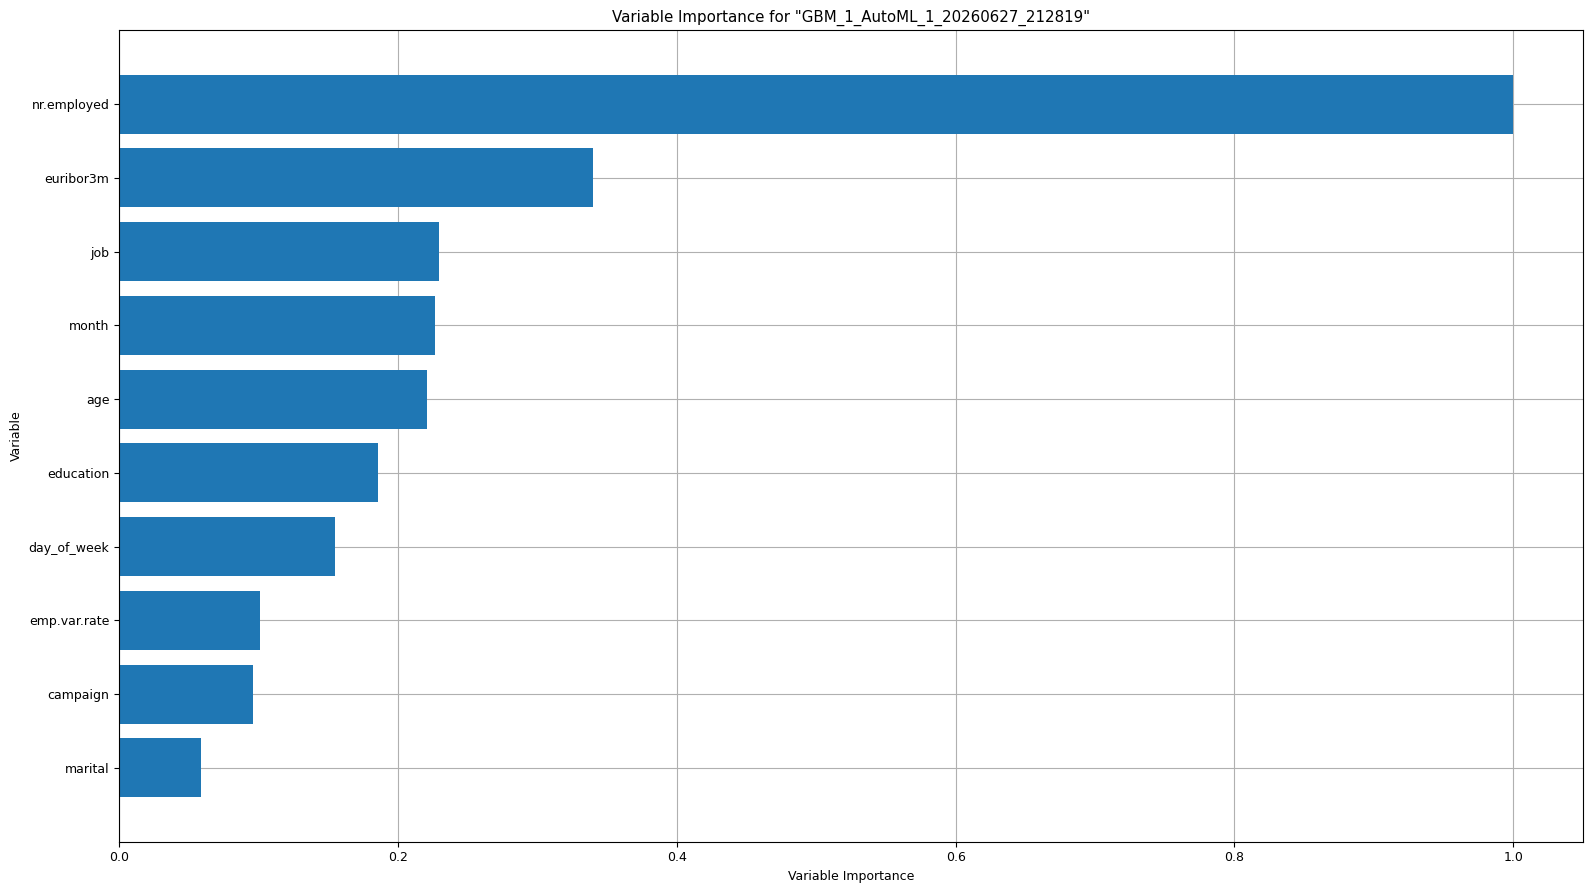

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

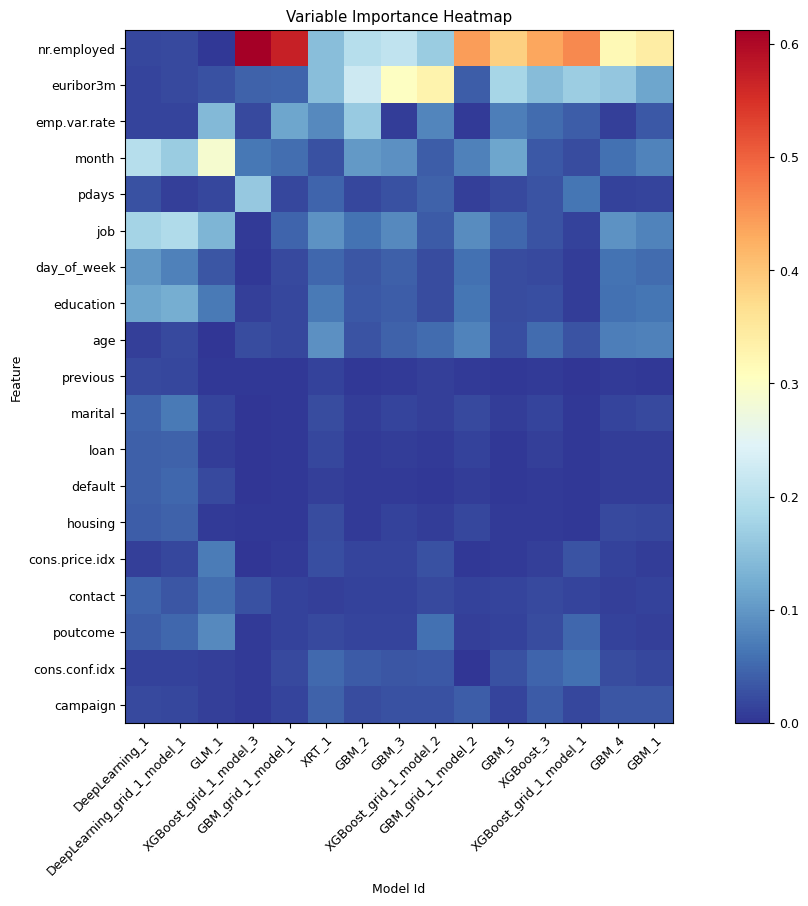

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

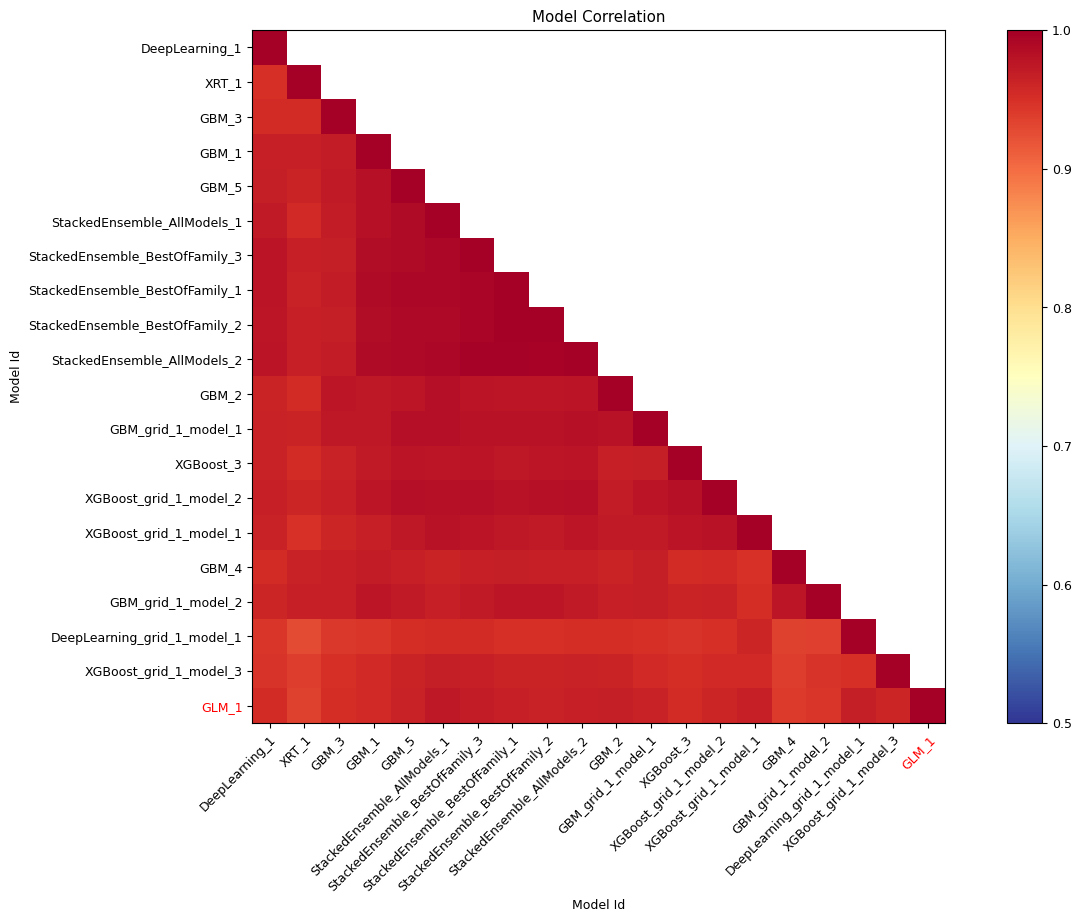

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

h2o.explain could not render all requested explanations.
this can happen for specific stacked ensembles or unsupported model types.
reason: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_462_sid_a21f (levels (tmp= py_461_sid_a21f (as.factor (cols_py py_460_sid_a21f np.str_('job'))))))", 'session_id': '_sid_a21f'}

Note was saved to: /content/h2o_marketing_level2_outputs/h2o_explain_report_note.txt


In [15]:
# determine the number of rows for the explainability frame to avoid memory overload
explain_n = min(EXPLAIN_N_ROWS, test_h2o.nrows)
explain_frame = test_h2o[:explain_n, :]

print(f"generating h2o explainability report using {explain_n} rows from the test set...")

try:
    explanations = h2o.explain(
        aml,
        explain_frame,
        render=True,
        include_explanations=[
            "leaderboard",
            "varimp",
            "varimp_heatmap",
            "model_correlation_heatmap",
            "shap_summary",
            "pdp",
            "ice",
            "residual_analysis",
        ],
    )
except Exception as e:
    print("h2o.explain could not render all requested explanations.")
    print("this can happen for specific stacked ensembles or unsupported model types.")
    print("reason:", e)

note_output_path = os.path.join(OUT_DIR, "h2o_explain_report_note.txt")
with open(note_output_path, "w") as f:
    f.write(
        "h2o.explain was successfully called on the automl object.\n"
        "rendered global explanation plots appear directly within the notebook output.\n"
        "all additional exported performance data is saved within this output directory.\n"
    )

print(f"Note was saved to: {note_output_path}")


# 12.1) Partial dependence plots for top features

In [16]:

try:
    varimp = leader.varimp()

    if varimp is not None:
        # extract the exact strings of the top 5 most important features
        top_features = [row[0] for row in varimp[:5]]

        print(f"generating global partial dependence plots for the top predictors: {top_features}")

        # compute and render the pdp graphs
        leader.partial_plot(
            data=test_h2o,
            cols=top_features
        )
    else:
        # some model architectures (like certain stacked ensembles) do not expose raw variable importances
        print(
            "partial dependence plots were skipped because "
            "the extracted leader model architecture does not natively support standard variable importance."
        )

except Exception as e:
    print("partial dependence plots could not be generated successfully.")
    print("reason for failure:", e)


partial dependence plots were skipped because the extracted leader model architecture does not natively support standard variable importance.


## 12.2) Local row-level explanations

In [17]:
# filter row indexes
local_rows = [i for i in LOCAL_EXPLAIN_ROW_INDEXES if i < test_h2o.nrows]

local_rows_path = os.path.join(OUT_DIR, "local_explanation_rows.csv")
pd.DataFrame({"row_index": local_rows}).to_csv(local_rows_path, index=False)

# loop through each selected customer row to generate local explanations
for row_idx in local_rows:
    print(f"generating local breakdown explanation for test dataset row index: {row_idx}")

    try:
        _ = h2o.explain_row(
            aml,
            test_h2o,
            row_index=row_idx,
            render=True,
        )
    except Exception as e:
        print(f"h2o.explain_row execution failed for row index {row_idx}.")
        print("reason for local failure:", e)


generating local breakdown explanation for test dataset row index: 0


# Leaderboard

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,p0,p1
GBM_5_AutoML_1_20260627_212819,0.81124,0.270622,0.467171,0.254652,0.277723,0.0771301,2124,0.018884,GBM,0,0.976994,0.0230057
XGBoost_3_AutoML_1_20260627_212819,0.810015,0.480866,0.473569,0.24746,0.385909,0.148926,3967,0.005122,XGBoost,0,0.846747,0.153253
GBM_grid_1_AutoML_1_20260627_212819_model_1,0.80919,0.270988,0.470703,0.256996,0.277975,0.0772703,2081,0.01723,GBM,0,0.972487,0.0275131
XGBoost_grid_1_AutoML_1_20260627_212819_model_2,0.808855,0.269849,0.463941,0.24433,0.276946,0.076699,2808,0.007248,XGBoost,0,0.917571,0.0824286
StackedEnsemble_AllModels_2_AutoML_1_20260627_212819,0.808165,0.267846,0.472357,0.243782,0.27516,0.0757132,24746,0.083141,StackedEnsemble,0,0.977281,0.0227187
StackedEnsemble_BestOfFamily_3_AutoML_1_20260627_212819,0.806926,0.268487,0.470944,0.256756,0.27548,0.0758894,16496,0.09542,StackedEnsemble,0,0.976971,0.023029
XGBoost_grid_1_AutoML_1_20260627_212819_model_1,0.806855,0.269598,0.467787,0.241935,0.276446,0.0764224,7574,0.004026,XGBoost,0,0.960214,0.0397859
StackedEnsemble_AllModels_1_AutoML_1_20260627_212819,0.806447,0.268277,0.472709,0.244937,0.275584,0.0759465,19663,0.044265,StackedEnsemble,0,0.976381,0.0236193
StackedEnsemble_BestOfFamily_2_AutoML_1_20260627_212819,0.804897,0.268975,0.470019,0.25183,0.275884,0.0761122,13949,0.053292,StackedEnsemble,0,0.977042,0.0229576
StackedEnsemble_BestOfFamily_1_AutoML_1_20260627_212819,0.804622,0.269092,0.470151,0.251497,0.275948,0.0761471,15656,0.028894,StackedEnsemble,0,0.97771,0.0222901


# SHAP Explanation

...

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,p0,p1
GBM_5_AutoML_1_20260627_212819,0.81124,0.270622,0.467171,0.254652,0.277723,0.0771301,2124,0.018884,GBM,0,0.923645,0.0763549
XGBoost_3_AutoML_1_20260627_212819,0.810015,0.480866,0.473569,0.24746,0.385909,0.148926,3967,0.005122,XGBoost,0,0.595854,0.404146
GBM_grid_1_AutoML_1_20260627_212819_model_1,0.80919,0.270988,0.470703,0.256996,0.277975,0.0772703,2081,0.01723,GBM,0,0.908732,0.0912684
XGBoost_grid_1_AutoML_1_20260627_212819_model_2,0.808855,0.269849,0.463941,0.24433,0.276946,0.076699,2808,0.007248,XGBoost,0,0.913352,0.0866479
StackedEnsemble_AllModels_2_AutoML_1_20260627_212819,0.808165,0.267846,0.472357,0.243782,0.27516,0.0757132,24746,0.083141,StackedEnsemble,0,0.932922,0.0670781
StackedEnsemble_BestOfFamily_3_AutoML_1_20260627_212819,0.806926,0.268487,0.470944,0.256756,0.27548,0.0758894,16496,0.09542,StackedEnsemble,0,0.935042,0.0649576
XGBoost_grid_1_AutoML_1_20260627_212819_model_1,0.806855,0.269598,0.467787,0.241935,0.276446,0.0764224,7574,0.004026,XGBoost,0,0.94108,0.0589198
StackedEnsemble_AllModels_1_AutoML_1_20260627_212819,0.806447,0.268277,0.472709,0.244937,0.275584,0.0759465,19663,0.044265,StackedEnsemble,0,0.940453,0.0595474
StackedEnsemble_BestOfFamily_2_AutoML_1_20260627_212819,0.804897,0.268975,0.470019,0.25183,0.275884,0.0761122,13949,0.053292,StackedEnsemble,0,0.943307,0.056693
StackedEnsemble_BestOfFamily_1_AutoML_1_20260627_212819,0.804622,0.269092,0.470151,0.251497,0.275948,0.0761471,15656,0.028894,StackedEnsemble,0,0.943448,0.0565519


# SHAP Explanation

> SHAP explanation shows contribution of features for a given instance. The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function. H2O implements TreeSHAP which when the features are correlated, can increase contribution of a feature that had no influence on the prediction.

h2o.explain_row execution failed for row index 2.
reason for local failure: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_561_sid_a21f (levels (tmp= py_560_sid_a21f (as.factor (cols_py py_558_sid_a21f np.str_('job'))))))", 'session_id': '_sid_a21f'}



#13) SHAP

In [18]:
# Sample background and SHAP datasets
X_background = test[FEATURES].sample(
    n=min(20, len(test)),
    random_state=42
)

X_shap = test[FEATURES].sample(
    n=min(30, len(test)),
    random_state=42
)

# defined H2O prediction function
def predict_final_pd_fn_h2o(data):
    # convert to Pandas DataFrame
    df = pd.DataFrame(data, columns=FEATURES)

    # target column
    tmp = df.copy()
    tmp[TARGET] = 0

    # Convert to H2O Frame
    h2o_frame = h2o.H2OFrame(tmp)
    # force target as factor for H2O
    h2o_frame[TARGET] = h2o_frame[TARGET].asfactor()

    # Generate predictions with leader model
    preds = leader.predict(h2o_frame).as_data_frame()

    # For binary classification, 'preds' contains columns: ['predict', 'p0', 'p1'] --> isolateing the probability of the positive class ('p1')
    pd_raw = preds['p1'].values

    return pd_raw

# using KernelExplainer and compute SHAP values
explainer = shap.KernelExplainer(
    predict_final_pd_fn_h2o,
    X_background
)

shap_values = explainer.shap_values(
    X_shap,
    nsamples=30
)


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow a

## 13.1) Globaler SHAP Summary Plot

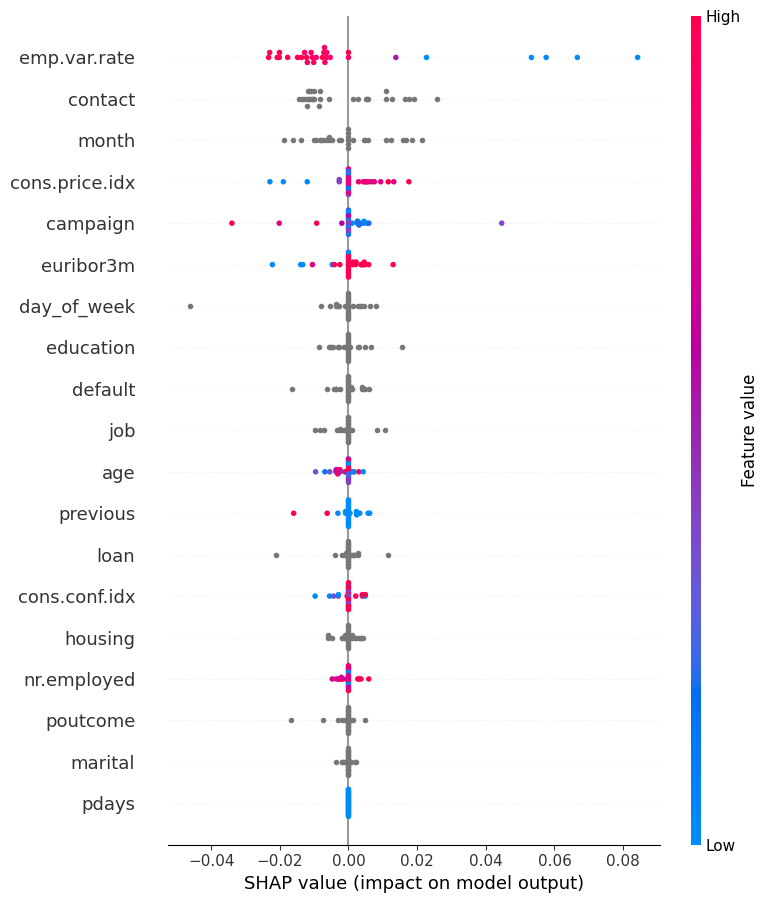

In [19]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)
plt.tight_layout()

plt.savefig(
    os.path.join(PLOT_DIR, "shap_summary_plot.png"),
    bbox_inches="tight",
    dpi=300
)
plt.show()
plt.close()


## 13.2) Globaler SHAP Summary Bar Plot

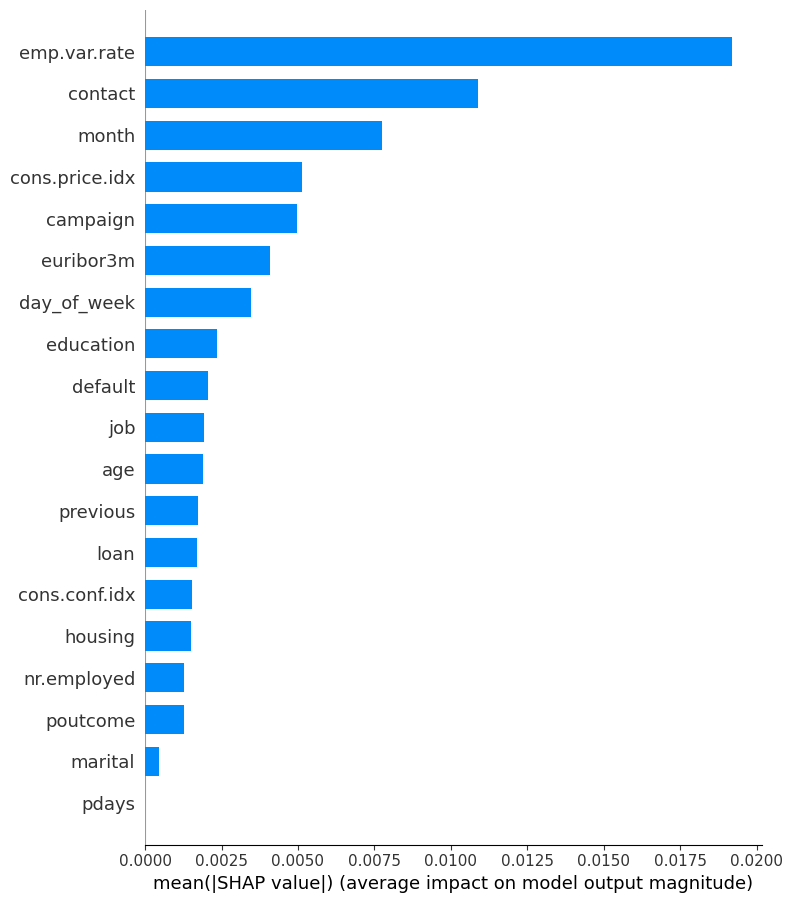

In [20]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOT_DIR, "shap_summary_bar_plot.png"),
    bbox_inches="tight",
    dpi=300
)
plt.show()
plt.close()


## 13.3) SHAP Local Waterfall Plot for High Efficiency Point (~15% Budget)

The 15% Budget Customer (The "Sure Winner")
* Why this person is important:

This customer belongs to one of the most valuable groups in the dataset. Customers with similar characteristics have a high probability of subscribing and are therefore associated with a high expected return on investment.
* What they mean:

This customer shows a combination of features that the model strongly associates with a successful subscription. By analyzing this individual, it is possible to identify the characteristics of an ideal subscriber and better understand which factors contribute to a high predicted probability of conversion. These insights can help identify customer groups that are likely to respond positively to marketing campaigns.

  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


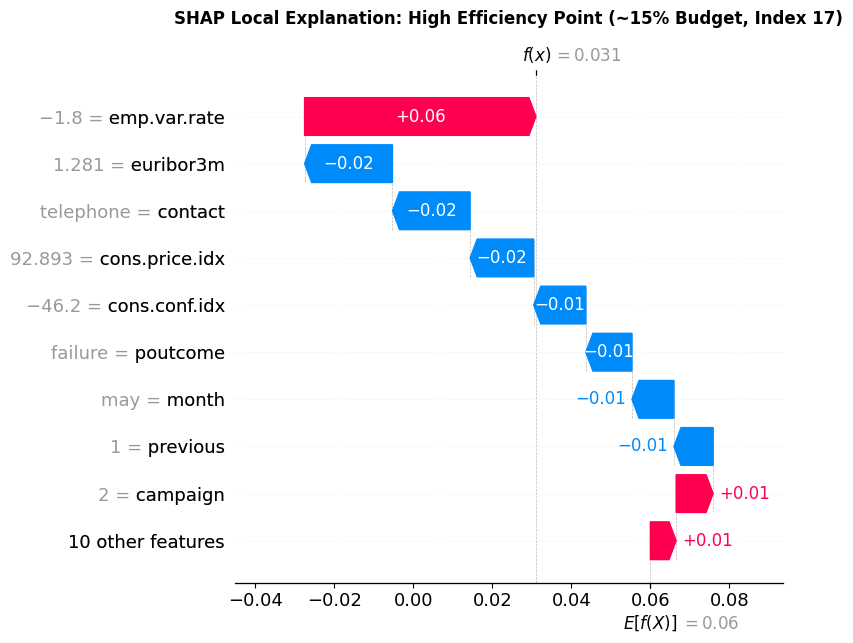

In [21]:
#  index from the 15% budget highlight row
idx_15 = row_15.index

# feature values as a clean 2D DataFrame row for the explainer
X_single_15 = test[FEATURES].loc[idx_15]

# Compute specific SHAP values
shap_values_single_15 = explainer.shap_values(X_single_15, nsamples=30)

# Create the Explanation object using 1D arrays
explanation_15 = shap.Explanation(
    values=shap_values_single_15[0],            # First row of the computed SHAP values
    base_values=explainer.expected_value,       # The average model prediction
    data=X_single_15.iloc[0].values,            # Extract the raw feature values as 1D array
    feature_names=FEATURES
)

# save plot
plt.figure(figsize=(9, 5))
shap.plots.waterfall(explanation_15, show=False)
plt.title(f"SHAP Local Explanation: High Efficiency Point (~15% Budget, Index {idx_15.values[0]})",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "shap_waterfall_budget_15.png"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()

## 13.4)  SHAP Local Waterfall Plot for Strategic Truncation Point (~50% Budget)

The 50% Budget Customer (The "The Decision Boundary Case")
* Why this person is important:

This customer is located close to the decision boundary of the campaign strategy. At this point, the expected benefit of contacting additional customers becomes lower, making marketing activities less cost-effective.
* What they mean:

This customer represents a case with a balanced combination of characteristics that support and discourage a subscription. As a result, the model assigns a medium probability of conversion. Analyzing this individual helps to better understand the decision boundary of the model and identify the factors that influence whether a customer is considered worth targeting within the available marketing budget.

  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


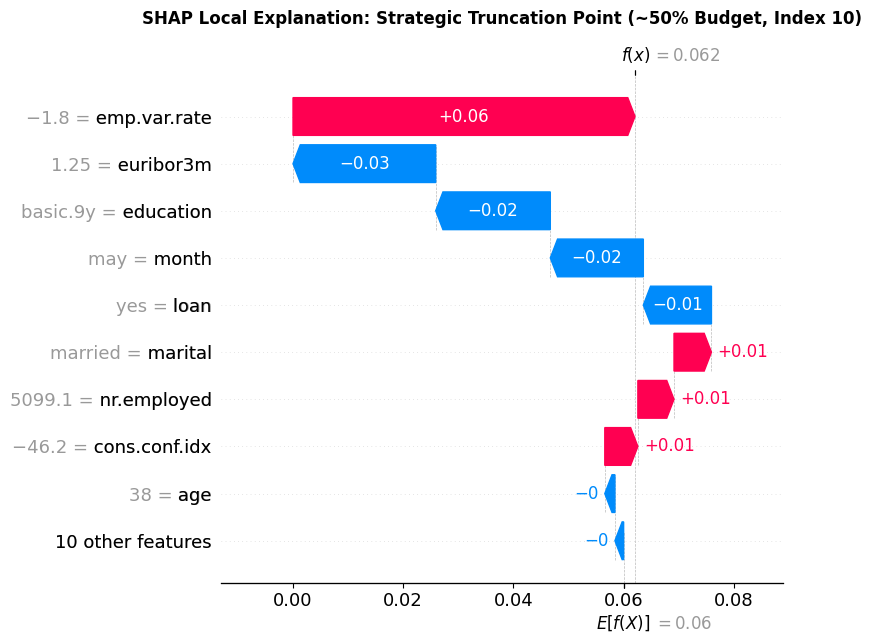

In [22]:
# index from the 50% budget highlight row
idx_50 = row_50.index

# feature values as a clean 2D DataFrame row for the explainer
X_single_50 = test[FEATURES].loc[idx_50]

# Compute specific SHAP values
shap_values_single_50 = explainer.shap_values(X_single_50, nsamples=30)

# Create the Explanation object using 1D arrays
explanation_50 = shap.Explanation(
    values=shap_values_single_50[0],
    base_values=explainer.expected_value,
    data=X_single_50.iloc[0].values,
    feature_names=FEATURES
)

# save plot
plt.figure(figsize=(9, 5))
shap.plots.waterfall(explanation_50, show=False)
plt.title(f"SHAP Local Explanation: Strategic Truncation Point (~50% Budget, Index {idx_50.values[0]})",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "shap_waterfall_budget_50.png"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()


# 14) LIME

In [23]:
# Data preparation
X_train = train[FEATURES].copy()
y_train = train[TARGET].astype(int)

X_test = test[FEATURES].copy()
y_test = test[TARGET].astype(int)

# One-Hot-Encoding for LIME
X_train_lime = pd.get_dummies(X_train, drop_first=False)
X_test_lime = pd.get_dummies(X_test, drop_first=False)

# Align test columns with training columns to maintain strict structure consistency
X_test_lime = X_test_lime.reindex(
    columns=X_train_lime.columns,
    fill_value=0
)

X_train_lime = X_train_lime.astype(float)
X_test_lime = X_test_lime.astype(float)

# Initialize LIME Explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train_lime.columns.tolist(),
    class_names=["No Response", "Subscriber"],
    mode="classification"
)


# prediction function (reverts dummy variables back to categorical text for H2O)
def predict_final_pd_from_encoded_h2o(data):
    df_encoded = pd.DataFrame(data, columns=X_train_lime.columns)
    df_original = pd.DataFrame(index=df_encoded.index)

    # Revert one-hot encoded dummy columns back to original categorical strings
    for col in X_train.columns:
        dummy_cols = [c for c in df_encoded.columns if c.startswith(f"{col}_")]

        if dummy_cols:
            df_original[col] = (
                df_encoded[dummy_cols]
                .idxmax(axis=1)
                .str[len(col) + 1:]
            )
        else:
            df_original[col] = df_encoded[col]

    # Enforce original feature column order for the H2O input schema
    df_original = df_original[X_train.columns]

    # Prepare temporary DataFrame with a dummy target column for H2O parsing
    tmp = df_original.copy()
    tmp[TARGET] = 0

    # Convert to native H2O Frame and  cast target as factor as needed for H20
    h2o_frame = h2o.H2OFrame(tmp)
    h2o_frame[TARGET] = h2o_frame[TARGET].asfactor()

    # predictions using the  leader model
    preds = leader.predict(h2o_frame).as_data_frame()

    # Isolate 'p1' column representing the subscriber probability
    pd_raw = preds['p1'].values
    return pd_raw


#  prediction wrapper for LIME (as it expects a 2D array with the probabilities for both classes)
def predict_proba_fn_lime_h2o(data):
    pd_final = predict_final_pd_from_encoded_h2o(data)
    return np.column_stack([
        1 - pd_final,  # Probability for "No" = 0
        pd_final       # Probability for "Yes" = 1
    ])


# Explain a single instance, here 0
instance_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[instance_idx].values,
    predict_fn=predict_proba_fn_lime_h2o,
    num_features=10
)

# Render visualization inside the Jupyter Notebook environment
lime_exp.show_in_notebook(show_table=True)

# save
fig = lime_exp.as_pyplot_figure()
plt.title(f'LIME Local Explanation for Customer (Index {instance_idx})', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'lime_marketing_explanation.png'), dpi=300, bbox_inches="tight")
plt.close()


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## 14.1) LIME Explanation for High Efficiency Point (around 15% Budget)

In [24]:
# index from the 15% budget highlight row in  Gain Chart
idx_15 = row_15.index[0]


lime_exp_15 = lime_explainer.explain_instance(
    data_row=X_test_lime.loc[idx_15].values,
    predict_fn=predict_proba_fn_lime_h2o,
    num_features=10
)


print(f"--- LIME Explanation for Customer at 15% Budget (Index: {idx_15}) ---")
lime_exp_15.show_in_notebook(show_table=True)

# save
fig_15 = lime_exp_15.as_pyplot_figure()
plt.title(f'LIME Local Explanation: High Efficiency Point (~15% Budget, Index {idx_15})',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'lime_explanation_budget_15.png'), dpi=300, bbox_inches="tight")
plt.close()


--- LIME Explanation for Customer at 15% Budget (Index: 17) ---


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## 14.2) LIME Explanation for Strategic Truncation Point (around 50% Budget)

In [25]:
# index from the 50% budget highlight row in  Gain Chart
idx_50 = row_50.index[0]

lime_exp_50 = lime_explainer.explain_instance(
    data_row=X_test_lime.loc[idx_50].values,
    predict_fn=predict_proba_fn_lime_h2o,
    num_features=10
)

print(f"--- LIME Explanation for Customer at 50% Budget (Index: {idx_50}) ---")
lime_exp_50.show_in_notebook(show_table=True)

# save
fig_50 = lime_exp_50.as_pyplot_figure()
plt.title(f'LIME Local Explanation: Strategic Truncation Point (~50% Budget, Index {idx_50})',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'lime_explanation_budget_50.png'), dpi=300, bbox_inches="tight")
plt.close()


--- LIME Explanation for Customer at 50% Budget (Index: 10) ---


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 15) Evaluation: ROC curve, PR curve, global metrics

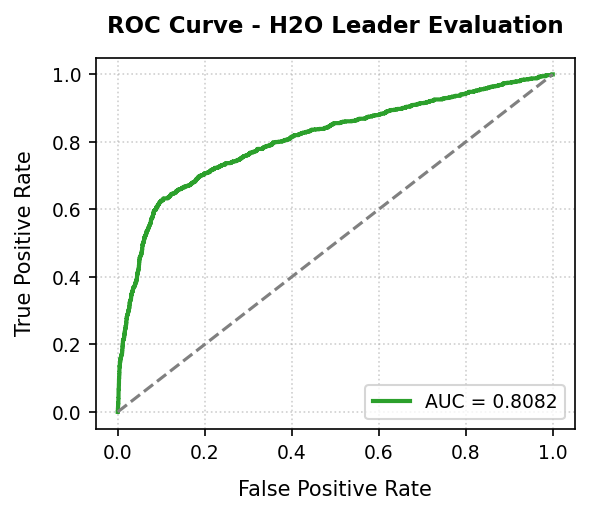

In [26]:
# compute false positive rate, true positive rate, and area under the curve for h2o
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4, 3.5), dpi=150)
plt.plot(fpr, tpr, color='#2ca02c', linewidth=2, label=f"AUC = {roc_auc:.4f}")

# plot the standard diagonal random classifier baseline
plt.plot([0, 1], [0, 1], linestyle="--", color='gray', linewidth=1.5)

plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel("False Positive Rate", fontsize=10, labelpad=8)
plt.ylabel("True Positive Rate", fontsize=10, labelpad=8)
plt.title("ROC Curve - H2O Leader Evaluation", fontsize=11, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()

# save plot
plt.savefig(
    os.path.join(PLOT_DIR, "roc_curve_h2o.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()


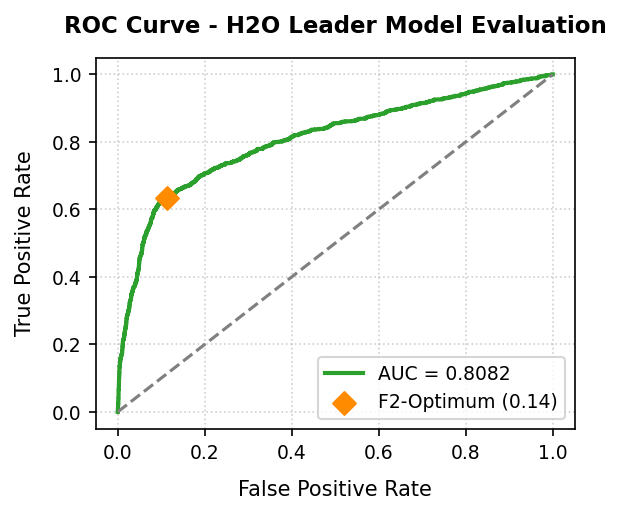

In [27]:
# Uses the H2O predicted probabilities extracted in the previous cells
fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    proba_test
)

roc_auc = auc(
    fpr,
    tpr
)


# Predict hard classes using the H2O-specific validation-selected F2 threshold
y_test_pred_f2 = (proba_test >= best_threshold_f2).astype(int)

# Extract confusion matrix to calculate the rates mathematically
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_f2).ravel()

# Calculate specific operating point coordinates
f2_tpr = tp / (tp + fn)  # True Positive Rate (Recall)
f2_fpr = fp / (fp + tn)  # False Positive Rate


#plot
plt.figure(figsize=(4, 3.5), dpi=150)

# Plot the continuous performance curve
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    color='#2ca02c',
    label=f"AUC = {roc_auc:.4f}"
)

# Plot the standard diagonal random classifier baseline
plt.plot([0,1], [0,1]
 ,
    linestyle="--",
    color="gray",
    linewidth=1.5
)


# Place the marker point f2 as a diamond on top of the curve
plt.scatter(
    f2_fpr,
    f2_tpr,
    color='darkorange',
    s=60,
    marker='D',
    zorder=5,
    label=f"F2-Optimum ({best_threshold_f2:.2f})"
)



plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.xlabel(
    "False Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.ylabel(
    "True Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.title(
    "ROC Curve - H2O Leader Model Evaluation",
    fontsize=11,
    fontweight="bold",
    pad=12
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()


#save
plt.savefig(
    os.path.join(PLOT_DIR, "roc_curve_h2o_with_f2.png"),
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


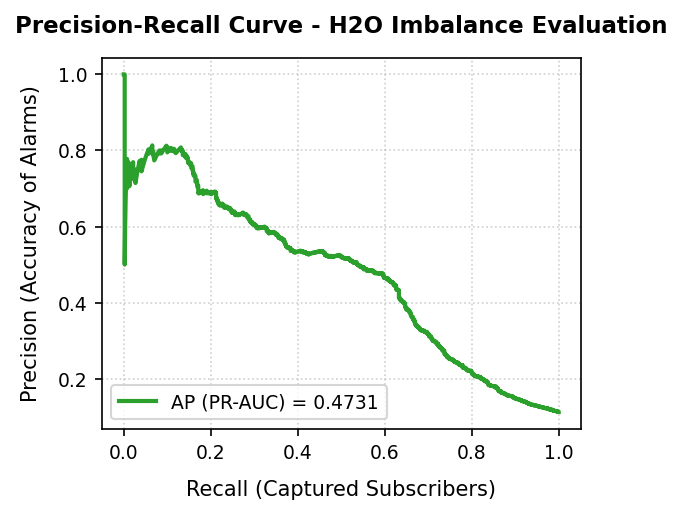

In [28]:
# compute precision, recall arrays and the average precision score for h2o
precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba_test)
ap_score = average_precision_score(y_test, proba_test)

# initialize the plot
plt.figure(figsize=(4, 3.5), dpi=150)
plt.plot(recall_vals, precision_vals, color='#2ca02c', linewidth=2, label=f"AP (PR-AUC) = {ap_score:.4f}")

plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel("Recall (Captured Subscribers)", fontsize=10, labelpad=8)
plt.ylabel("Precision (Accuracy of Alarms)", fontsize=10, labelpad=8)
plt.title("Precision-Recall Curve - H2O Imbalance Evaluation", fontsize=11, fontweight='bold', pad=12)
plt.legend(loc="lower left", fontsize=9)
plt.tight_layout()

# save plot
plt.savefig(
    os.path.join(PLOT_DIR, "precision_recall_curve_h2o.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()


In [33]:
# performance objects for validation and unseen test data
performance_val = leader.model_performance(valid=True)
performance_test = leader.model_performance(test_data=test_h2o)

# extract precision-recall area under the curve (aucpr / pr-auc) scores
pr_auc_val = performance_val.aucpr()
pr_auc_test = performance_test.aucpr()

# extract classic receiver operating characteristic area under the curve (auc / roc-auc) scores
roc_auc_val = performance_val.auc()
roc_auc_test = performance_test.auc()

# extract default recall metric (true positive rate) from the h2o performance objects
# as h2o returns a list of recalls per threshole --> extract the default metric
recall_val = performance_val.recall()[0][1]
recall_test = performance_test.recall()[0][1]

print("global model metrics (independent of classification thresholds):")
print("=" * 60)
print(f"validation pr-auc (focus on class 1): {pr_auc_val:.4f}")
print(f"test       pr-auc (focus on class 1): {pr_auc_test:.4f}")
print("-" * 60)
print(f"validation roc-auc (standard metric): {roc_auc_val:.4f}")
print(f"test       roc-auc (standard metric): {roc_auc_test:.4f}")
print("-" * 60)
print(f"validation recall  (true positive rate): {recall_val:.4f}")
print(f"test       recall  (true positive rate): {recall_test:.4f}")
print("=" * 60)


global model metrics (independent of classification thresholds):
validation pr-auc (focus on class 1): 0.4661
test       pr-auc (focus on class 1): 0.4724
------------------------------------------------------------
validation roc-auc (standard metric): 0.8083
test       roc-auc (standard metric): 0.8082
------------------------------------------------------------
validation recall  (true positive rate): 1.0000
test       recall  (true positive rate): 1.0000


In [34]:
# summary of exported artifacts and key performance indicators (h2o)

print("=" * 60)
print("H2O marketing evaluation completed")
print("=" * 60)

print(f"saved operational outputs: {OUT_DIR}")
print(f"saved visualization outputs: {PLOT_DIR}")

print("-" * 60)
print(f"test roc-auc (global ranking quality):    {roc_auc_test:.4f}")
print(f"test pr-auc  (positive-class precision):  {pr_auc_test:.4f}")
print("=" * 60)
print(f"Final test F2-score (Threshold {best_threshold_f2:.2f}):  {f2_sota:.4f}")
print("-" * 60)
print("Business metrics for the campaign:")
print(f"-> Campaign recall (hit rate):        {rec_f2 * 100:.1f}%")
print(f"-> Campaign precision (efficiency):   {prec_f2 * 100:.1f}%")
print("=" * 60)


H2O marketing evaluation completed
saved operational outputs: /content/h2o_marketing_level2_outputs
saved visualization outputs: /content/h2o_marketing_level2_outputs/plots
------------------------------------------------------------
test roc-auc (global ranking quality):    0.8082
test pr-auc  (positive-class precision):  0.4724
Final test F2-score (Threshold 0.14):  0.5722
------------------------------------------------------------
Business metrics for the campaign:
-> Campaign recall (hit rate):        63.3%
-> Campaign precision (efficiency):   41.4%


# 15) Model package

In [30]:
#  detecting the cut-off grade where cumulative budget hits exactly 50% for h2o
calculated_cutoff_grade_h2o = int(response_grade_table_test_h2o[response_grade_table_test_h2o["budget_allocation_percent"] <= 50.0]["response_grade"].max())

model_package = {
    "use_case": "marketing_term_deposit_subscription",
    "framework": "h2o_automl",
    "level": 1,
    "focus": "performance_baseline",
    "target": TARGET,
    "positive_class": int(POS_LABEL),
    "negative_class": int(NEG_LABEL),
    "primary_metric": PRIMARY_METRIC,
    "time_limit_seconds": int(MAX_RUNTIME_SECS),
    "max_models": MAX_MODELS,
    "best_model_id": str(leader.model_id),
    "saved_model_path": str(saved_model_path),

    # strategic business constraints (replaces legacy hard thresholds)
    "strategic_budget_cap_percent": 50.0,  # here: fixed business constraint defined  (can be changed)
    "applied_cutoff_grade": calculated_cutoff_grade_h2o,  # dynamic cut-off grade calculated from data

    # dataset dimensions extracted directly from h2o frames
    "n_train": int(train_h2o.nrow),
    "n_validation": int(val_h2o.nrow),
    "n_test": int(test_h2o.nrow),
    "n_features": int(len(FEATURES)),
    "note": (
        "performance-oriented h2o automl marketing classification baseline. "
        "lower groups are dynamically truncated based on the strategic budget cap."
    )
}

#  h2o model package metadata to json file
model_package_path = os.path.join(OUT_DIR, "model_package.json")
with open(model_package_path, "w", encoding="utf-8") as f:
    json.dump(model_package, f, indent=2)

print(f"h2o model metadata saved to: {model_package_path}")


h2o model metadata saved to: /content/h2o_marketing_level2_outputs/model_package.json


# 16) Print Summery

In [31]:
# high-level directories and global test metrics for quick verification
print(f"saved h2o operational outputs to: {OUT_DIR}")
print(f"saved h2o high-resolution plots to: {PLOT_DIR}")

print(f"test roc-auc (global sorting power):     {roc_auc_test:.4f}")
print(f"test pr-auc  (global precision horizon): {pr_auc_test:.4f}")
print("=" * 60)


saved h2o operational outputs to: /content/h2o_marketing_level2_outputs
saved h2o high-resolution plots to: /content/h2o_marketing_level2_outputs/plots
test roc-auc (global sorting power):     0.8082
test pr-auc  (global precision horizon): 0.4724


In [32]:
# Export predictions for cross-model comparison (h2o)

comparison_export = pd.DataFrame({
    "y_true": y_test,
    "y_proba": proba_test
})


comparison_export.to_csv(
    "comparison_predictions_h2o_leader_level2.csv",
    index=False
)

print("Saved: comparison_predictions_h2o_leader2.csv")


Saved: comparison_predictions_h2o_leader2.csv
